In [1]:
import csv
import os
import random
import re
from importlib.util import find_spec
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from qwen_vl_utils import process_vision_info
from torchvision.io import read_image
from torchvision.transforms.functional import to_pil_image
from tqdm.auto import tqdm
from transformers import AutoProcessor, GenerationConfig, Qwen2VLForConditionalGeneration
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

In [2]:
# Overall settings
SEED = 42
RANDOM_START = True
OVERWRITE = False

# PGD parameters
EPSILON = 8 / 255
ALPHA = 2 / 255
PGD_STEPS = 30
CHECKPOINT = 10

# Directory
def find_project_root(start=Path.cwd(), project_name="attack-on-medvqa"):
    start = Path(start).resolve()

    for path in [start, *start.parents]:
        if path.name == project_name:
            return path

    raise FileNotFoundError(f"Could not find project root named {project_name}")

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data" / "OmniMedVQA" / "sample_mri"
ADV_IMAGE_DIR = DATA_ROOT / "images_pgd"
CSV_PATH = PROJECT_ROOT / "result"
PGD_LOSS_CSV_PATH = CSV_PATH / "pgd_loss.csv"
PGD_RESULT_CSV_PATH = CSV_PATH / "pgd_result.csv"

ADV_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(DATA_ROOT)
print(ADV_IMAGE_DIR)
print(CSV_PATH)
print(PGD_LOSS_CSV_PATH)
print(PGD_RESULT_CSV_PATH)

/home/euro/code/sheffield/dissertation/attack-on-medvqa
/home/euro/code/sheffield/dissertation/attack-on-medvqa/data/OmniMedVQA/sample_mri
/home/euro/code/sheffield/dissertation/attack-on-medvqa/data/OmniMedVQA/sample_mri/images_pgd
/home/euro/code/sheffield/dissertation/attack-on-medvqa/result
/home/euro/code/sheffield/dissertation/attack-on-medvqa/result/pgd_loss.csv
/home/euro/code/sheffield/dissertation/attack-on-medvqa/result/pgd_result.csv


# Load Model

In [3]:
os.environ["HF_HOME"] = "/data/huggingface_cache"
MODEL_PATH = "JZPeterPan/MedVLM-R1"

cuda_available = torch.cuda.is_available()
device = "cuda" if cuda_available else "cpu"
print(f"Using device: {device}")

flash_attn_available = find_spec("flash_attn") is not None
attn_implementation = "flash_attention_2" if flash_attn_available else "sdpa"
print(f"Using attention implementation: {attn_implementation}")

dtype = torch.bfloat16 if cuda_available else torch.float32
print(f"Using dtype: {dtype}")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    dtype=dtype,
    attn_implementation=attn_implementation,
    device_map="auto",
)
model.eval()
model.requires_grad_(False)
model.config.use_cache = False

processor = AutoProcessor.from_pretrained(MODEL_PATH)
image_processor = processor.image_processor

config = GenerationConfig(
    max_new_tokens=1024,
    do_sample=False,  
    temperature=1, 
    num_return_sequences=1,
    pad_token_id=151643,
)

print("Model and processor loaded successfully.")

Using device: cuda
Using attention implementation: sdpa
Using dtype: torch.bfloat16


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Model and processor loaded successfully.


# Functions

## Helper Functions

In [4]:
QUESTION_TEMPLATE = """
    {Question}
    Your task:
    1. Think through the question step by step, enclose your reasoning process in <think>...</think> tags.
    2. Then provide the correct single-letter choice (A, B, C, D,...) inside <answer>...</answer> tags.
    3. No extra information or text outside of these tags.
    """

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
def get_adversarial_image_path(image_path, step=None):
    if step is None:
        return ADV_IMAGE_DIR / f"{Path(image_path).stem}_adv.png"
    return ADV_IMAGE_DIR / f"{Path(image_path).stem}_adv_step{step}.png"

def get_magnitude_image_path(image_path, step=None):
    if step is None:
        return ADV_IMAGE_DIR / f"{Path(image_path).stem}_mag.png"
    return ADV_IMAGE_DIR / f"{Path(image_path).stem}_mag_step{step}.png"

# ///////////////////////////////////////////////////

def get_perturbation_image_path(image_path, step=None):
    if step is None:
        return ADV_IMAGE_DIR / f"{Path(image_path).stem}_perturbation.png"
    return ADV_IMAGE_DIR / f"{Path(image_path).stem}_perturbation_step{step}.png"

def rgb_perturbation_to_pil(perturbation, epsilon=EPSILON):
    """
    Visualize signed RGB perturbation.

    - 0 perturbation -> gray
    - channel-dependent positive/negative changes -> color
    - -epsilon -> 0
    - 0        -> 0.5
    - +epsilon -> 1
    """
    visual = perturbation / (2 * epsilon) + 0.5
    visual = visual.clamp(0, 1)

    return tensor_to_pil(visual)
# ///////////////////////////////////////////////////

def load_image_tensor(image_path):
    image = read_image(image_path).float() / 255.0

    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)
    if image.shape[0] > 3:
        image = image[:3]

    return image.clamp(0, 1)
    
def tensor_to_pil(image_tensor):
    return to_pil_image(image_tensor.detach().cpu().float().clamp(0, 1))

def perturbation_to_pil(perturbation, epsilon=EPSILON):
    magnitude = perturbation.abs().max(dim=0).values / epsilon
    return tensor_to_pil(magnitude)

def extract_answer(output_text, tag="answer"):
    match = re.search(rf"<{tag}>\s*(.*?)\s*</{tag}>", output_text, re.DOTALL)
    return match.group(1).strip() if match else None
    
def plot_loss_curve(loss_history, image_name=None, save_path=None, checkpoints=None):
    plt.figure(figsize=(8, 4))
    x = range(1, len(loss_history) + 1)
    plt.plot(x, loss_history, marker="o", color="indigo")
    
    if checkpoints is not None:
        for cp in checkpoints:
            plt.axvline(x=cp, linestyle="-", linewidth=2, color="indigo", alpha=0.3)
    
    if image_name is not None:
        plt.title(f"PGD loss curve: {image_name}")
    else:
        plt.title("PGD loss curve")
        
    plt.xlabel("PGD step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)

    plt.show()
    
def run_model(question, image_path=None):
    
    if image_path is None:
        image_path = DATA_ROOT / question["image"][0]
    else:
        image_path = DATA_ROOT / image_path 
        
    message = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path.resolve().as_uri()},
            {"type": "text","text": QUESTION_TEMPLATE.format(Question=question["problem"])}
            ]
    }]
    
    text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True) 
    image_inputs, video_inputs = process_vision_info(message)
    
    inputs_adv = processor(
        text=text,
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(device)
    
    generated_ids = model.generate(**inputs_adv, use_cache=True, max_new_tokens=1024, do_sample=False, generation_config=config)
    generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs_adv.input_ids, generated_ids)]
    output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
    
    return output_text[0] 
    

## PGD Attack Function

In [5]:
def get_image_info(image_tensor):
    # Processor settings
    patch_size = image_processor.patch_size
    merge_size = image_processor.merge_size

    resized_h, resized_w = smart_resize(
        image_tensor.shape[-2],
        image_tensor.shape[-1],
        factor=patch_size * merge_size,
        min_pixels=image_processor.size["shortest_edge"],
        max_pixels=image_processor.size["longest_edge"],
    )
    
    grid_t = 1  # = 1 for single image
    grid_h = resized_h // patch_size
    grid_w = resized_w // patch_size
    
    image_grid_thw = torch.tensor(
        [[grid_t, grid_h, grid_w]],
        device=image_tensor.device,
        dtype=torch.long,
    )

    return resized_h, resized_w, image_grid_thw

def process_image(image_tensor, resized_h, resized_w):
    patch_size = image_processor.patch_size
    merge_size = image_processor.merge_size
    temporal_patch_size = image_processor.temporal_patch_size

    image = F.interpolate(
        image_tensor.unsqueeze(0),
        size=(resized_h, resized_w),
        mode="bicubic",
        align_corners=False,
    ).clamp(0, 1)

    # Normalize
    mean = image.new_tensor(image_processor.image_mean).view(1, 3, 1, 1)
    std = image.new_tensor(image_processor.image_std).view(1, 3, 1, 1)
    patches = (image - mean) / std

    # Temporal patch
    remainder = patches.shape[0] % temporal_patch_size
    if remainder != 0:
        repeat_count = temporal_patch_size - remainder
        patches = torch.cat([patches, patches[-1:].repeat(repeat_count, 1, 1, 1)], dim=0)

    # Grid size
    channels = patches.shape[1]
    grid_t = patches.shape[0] // temporal_patch_size
    grid_h = resized_h // patch_size
    grid_w = resized_w // patch_size

    patches = patches.reshape(
        grid_t, temporal_patch_size, channels,
        grid_h // merge_size, merge_size, patch_size,
        grid_w // merge_size, merge_size, patch_size,
    )

    patches = patches.permute(0, 3, 6, 4, 7, 2, 1, 5, 8)

    pixel_values = patches.reshape(
        grid_t * grid_h * grid_w,
        channels * temporal_patch_size * patch_size * patch_size,
    )

    return pixel_values

def build_attack_input(tensor_image, problem, target):
    message = [{
        "role": "user",
        "content": [
            {"type": "image", "image": "file://placeholder.png"},
            {"type": "text", "text": QUESTION_TEMPLATE.format(Question=problem)},
        ],
    }]

    prompt_text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
    target_text = f"<answer>{target}</answer>"

    inputs_adv = processor(
        text=[prompt_text + target_text],
        images=[tensor_to_pil(tensor_image)],
        padding=True,
        return_tensors="pt",
    ).to(device)

    target_ids = processor.tokenizer(
        target_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).input_ids.to(device)
    
    target_len = target_ids.size(1)
    labels = torch.full_like(inputs_adv.input_ids, -100)
    labels[:, -target_len:] = inputs_adv.input_ids[:, -target_len:]

    return inputs_adv, labels

def pgd_attack(
    question,
    seed,
    epsilon=EPSILON,
    alpha=ALPHA,
    steps=PGD_STEPS,
    random_start=RANDOM_START,
    target=None,
    plot=True
):
    set_seed(seed)
    
    image_path = DATA_ROOT / question["image"][0]
    problem = question["problem"]
    # Minimize loss for targeted attack, maximize loss for untargeted attack
    direction = -1 if target is not None else 1
    if target is None:
        target = question["solution"]

    # Image paths
    img_ori = load_image_tensor(image_path).to(device).detach()
    adversarial_path = get_adversarial_image_path(image_path)
    # ///////////////////////////////////////////////////
    perturbation_path = get_perturbation_image_path(image_path)
    # ///////////////////////////////////////////////////
    magnitude_path = get_magnitude_image_path(image_path)

    resized_h, resized_w, image_grid_thw = get_image_info(img_ori)
    image_grid_thw = image_grid_thw.to(device)

    inputs, labels = build_attack_input(
        tensor_image=img_ori,
        problem=problem,
        target=target,
    )

    # Initialize adversarial image
    if random_start:
        img_adv = img_ori + torch.empty_like(img_ori).uniform_(-epsilon, epsilon)
        img_adv = img_adv.clamp(0, 1)
    else:
        img_adv = img_ori.clone()

    # Epsilon bounds
    lower_bound = (img_ori - epsilon).clamp(0, 1)
    upper_bound = (img_ori + epsilon).clamp(0, 1)

    loss_history = []

    # Attack loop
    for step in tqdm(range(steps), desc=f"PGD {Path(image_path).name}", leave=False):
        
        # Restart computation graph
        img_adv = img_adv.detach().requires_grad_(True)

        # Process image
        pixel_values = process_image(
            img_adv,
            resized_h=resized_h,
            resized_w=resized_w,
        )

        # Inject adversarial image into inputs
        inputs_adv = {
            **inputs,
            "pixel_values": pixel_values.to(device=device, dtype=dtype),
            "image_grid_thw": image_grid_thw,
        }

        # Clear gradients
        model.zero_grad(set_to_none=True)

        # Forward and backward pass
        outputs = model(**inputs_adv, labels=labels, use_cache=False)
        loss = outputs.loss
        loss.backward()
        
        if img_adv.grad is None:
            raise RuntimeError(
                "img_adv.grad is None."
            )
        
        loss_value = loss.detach().float().cpu().item()
        loss_history.append(loss_value)

        # Update adversarial image
        with torch.no_grad():
            img_adv = img_adv + direction * alpha * img_adv.grad.sign()
            img_adv = img_adv.clamp(min=lower_bound, max=upper_bound)
            
        # Save checkpoint images
        if CHECKPOINT > 0:
            if (step + 1) % CHECKPOINT == 0 or (step + 1) == steps:
                tensor_to_pil(img_adv).save(get_adversarial_image_path(image_path, step=step + 1))
                perturbation = (img_adv - img_ori).detach().cpu()
                perturbation_to_pil(perturbation, epsilon=epsilon).save(get_magnitude_image_path(image_path, step=step + 1))
            

        # Clean up memory
        del inputs_adv, outputs, loss

    # Calculate perturbation
    perturbation = (img_adv - img_ori).detach().cpu()

    # Save images
    tensor_to_pil(img_adv).save(adversarial_path)
    perturbation_to_pil(perturbation, epsilon=epsilon).save(magnitude_path)
    
    # Plot loss curve
    if plot:
        plot_loss_curve(loss_history,image_name=Path(image_path).name, checkpoints=list(range(CHECKPOINT, PGD_STEPS + 1, CHECKPOINT)))
    
    return loss_history

# Image Cases

In [6]:
all_questions = [
    # {"image": ["images/mdb146.png"], "problem": "What content appears in this image?\nA) Cardiac tissue\nB) Breast tissue\nC) Liver tissue\nD) Skin tissue", "solution": "B", "answer": "Breast tissue"},
    # {"image": ["images/person19_virus_50.jpeg"], "problem": "What content appears in this image?\nA) Lungs\nB) Bladder\nC) Brain\nD) Heart", "solution": "A", "answer": "Lungs"},
    # {"image": ["images/abd-normal023599.png"], "problem": "Is any abnormality evident in this image?\nA) No\nB) Yes.", "solution": "A", "answer": "No"},
    # {"image": ["images/foot089224.png"], "problem": "Which imaging technique was utilized for acquiring this image?\nA) MRI\nB) Electroencephalogram (EEG)\nC) Ultrasound\nD) Angiography", "solution": "A", "answer": "MRI"},
    # {"image": ["images/knee031316.png"], "problem": "What can be observed in this image?\nA) Chondral abnormality\nB) Bone density loss\nC) Synovial cyst formation\nD) Ligament tear", "solution": "A", "answer": "Chondral abnormality"},
    # {"image": ["images/shoulder045906.png"], "problem": "What can be visually detected in this picture?\nA) Bone fracture\nB) Soft tissue fluid\nC) Blood clot\nD) Tendon tear", "solution": "B", "answer": "Soft tissue fluid"},
    # {"image": ["images/brain003631.png"], "problem": "What attribute can be observed in this image?\nA) Focal flair hyperintensity\nB) Bone fracture\nC) Vascular malformation\nD) Ligament tear", "solution": "A", "answer": "Focal flair hyperintensity"},
    # {"image": ["images/mrabd005680.png"], "problem": "What can be observed in this image?\nA) Pulmonary embolism\nB) Pancreatic abscess\nC) Intraperitoneal mass\nD) Cardiac tamponade", "solution": "C", "answer": "Intraperitoneal mass"},
    {
            "image": ["images/mod-mri_000777.png"],
            "problem": "What can be observed in this image? A)Carpal tunnel syndrome, B)Tendonitis, C)Plantar fasciitis, D)Achilles pathology",
            "solution": "D",
            "answer": "Achilles pathology"
        }
]

pprint(all_questions[0])

{'answer': 'Achilles pathology',
 'image': ['images/mod-mri_000777.png'],
 'problem': 'What can be observed in this image? A)Carpal tunnel syndrome, '
            'B)Tendonitis, C)Plantar fasciitis, D)Achilles pathology',
 'solution': 'D'}


# Perform Attack

Generating PGD images:   0%|          | 0/1 [00:00<?, ?it/s]

PGD mod-mri_000777.png:   0%|          | 0/30 [00:00<?, ?it/s]

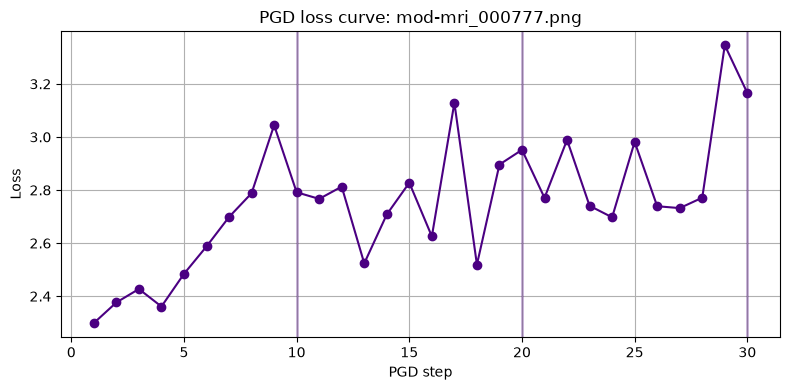

Finished attacking image 1/1:
 mod-mri_000777, Final Loss: 3.165728


In [7]:
loss = []
target = None

for index, question in tqdm(list(enumerate(all_questions, start=1)), desc="Generating PGD images"):
    image_name = Path(question["image"][0]).stem
    # seed = SEED + index if RANDOM_START else SEED
    seed = SEED
    
    loss_history  = pgd_attack(
        question=question,
        seed=seed,
        target=target,
        )
    
    for step, loss_value in enumerate(loss_history, start=1):
            loss.append({
                "image_name": image_name,
                "step": step,
                "loss": f"{loss_value:.6f}",
                "epsilon": EPSILON,
                "alpha": ALPHA,
                "seed": seed,
                "random_start": RANDOM_START,
                "target": target
            })
    
    print(f"Finished attacking image {index}/{len(all_questions)}:\n {image_name}, Final Loss: {loss_history[-1]:.6f}")

with PGD_LOSS_CSV_PATH.open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=loss[0].keys())
    writer.writeheader()
    writer.writerows(loss)

# Inference

## Inference Batch

Running inference:   0%|          | 0/1 [00:00<?, ?it/s]

`generation_config` default values have been modified to match model-specific defaults: {'do_sample': True, 'use_cache': None, 'temperature': 0.01, 'top_k': 1, 'top_p': 0.001, 'bos_token_id': 151643, 'eos_token_id': [151645, 151643], 'attn_implementation': 'flash_attention_2'}. If this is not desired, please set these values explicitly.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Image: mod-mri_000777.png
Question: What can be observed in this image? A)Carpal tunnel syndrome, B)Tendonitis, C)Plantar fasciitis, D)Achilles pathology
Solution: D
Original Answer: D
Adversarial Answer: C
Original Thought:  The image is a magnetic resonance imaging (MRI) scan of the foot, specifically focusing on the ankle and foot structures. The scan shows a cross-sectional view of the ankle joint.
Adversarial Thought: The image appears to be a stylized or pixelated representation of a face, which makes it difficult to identify specific anatomical structures. However, the image does not show any visible signs of carpal tunnel syndrome, tendonitis, plantar fasciitis, or Achilles pathology.
Attack Success: True


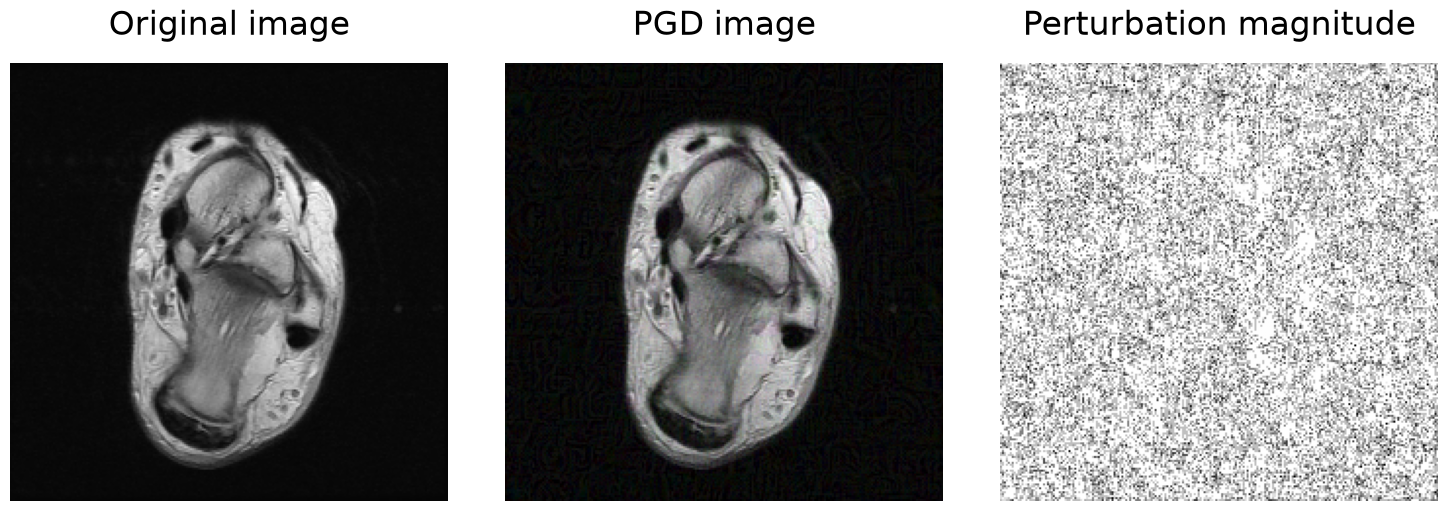

Results not saved.


In [8]:
SAVE_PGD_RESULT = False
result = []

for question in tqdm(all_questions, desc="Running inference"):
    image_path = DATA_ROOT / question["image"][0]
    image_name = image_path.name
    adv_image_path = get_adversarial_image_path(image_name)
    mag_image_path = get_magnitude_image_path(image_name)
    
    if not adv_image_path.exists():
        print(f"Adversarial image not found for {image_name}. Skipping inference.")
        continue
    
    problem = question["problem"]
    solution = question["solution"]
    original_output = run_model(question)
    original_answer = extract_answer(original_output, tag="answer")
    original_thought = extract_answer(original_output, tag="think")
    adversarial_output = run_model(question, image_path=adv_image_path)
    adversarial_answer = extract_answer(adversarial_output, tag="answer")
    adversarial_thought = extract_answer(adversarial_output, tag="think")
    attack_success = (original_answer == solution) and not (adversarial_answer == solution)
    
    print(f"Image: {image_name}")
    print(f"Question: {problem}")
    print(f"Solution: \033[92m{solution}\033[0m")
    print(f"Original Answer: \033[94m{original_answer}\033[0m")
    print(f"Adversarial Answer: \033[91m{adversarial_answer}\033[0m")
    print(f"Original Thought: \033[94m {original_thought}\033[0m")
    print(f"Adversarial Thought: \033[91m{adversarial_thought}\033[0m")
    print(f"Attack Success: \033[93m{attack_success}\033[0m")
    
    if SAVE_PGD_RESULT:
        result.append({
            "image_name": image_name,
            "problem": problem,
            "solution": solution,
            "original_answer": original_answer,
            "adversarial_answer": adversarial_answer,
            "original_thought": original_thought,
            "adversarial_thought": adversarial_thought,
            "attack_success": attack_success,
            "epsilon": EPSILON,
            "alpha": ALPHA,
            "steps": PGD_STEPS,
            "seed": SEED,
            "random_start": RANDOM_START,
            "target": target,
        })
        
    original_pil = Image.open(image_path)
    adversarial_pil = Image.open(adv_image_path)
    magnitude_pil = Image.open(mag_image_path)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_pil, cmap="gray")
    axes[0].set_title("Original image", fontsize=24, pad=20)
    axes[0].axis("off")
    axes[1].imshow(adversarial_pil, cmap="gray")
    axes[1].set_title("PGD image", fontsize=24, pad=20)
    axes[1].axis("off")
    axes[2].imshow(magnitude_pil, cmap="gray")
    axes[2].set_title("Perturbation magnitude", fontsize=24, pad=20)
    axes[2].axis("off")
    plt.tight_layout()
    
    save_path = Path("pgd_example.png")
    fig.savefig(
        save_path,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.1,
    )
    
    plt.show()

if SAVE_PGD_RESULT and result:
    with PGD_RESULT_CSV_PATH.open("w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=result[0].keys())
        writer.writeheader()
        writer.writerows(result)
    print(f"PGD results saved to {PGD_RESULT_CSV_PATH}")
else:
    print("Results not saved.")

## Inference on Checkpoint Images

Running inference:   0%|          | 0/1 [00:00<?, ?it/s]

Image: mod-mri_000777.png


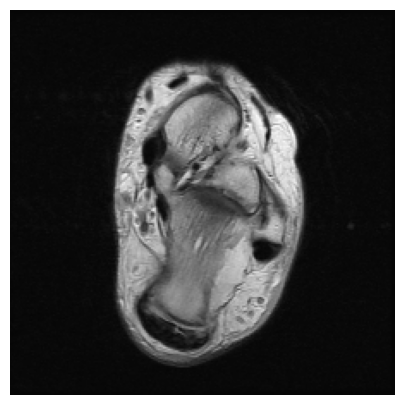

Question: What can be observed in this image? A)Carpal tunnel syndrome, B)Tendonitis, C)Plantar fasciitis, D)Achilles pathology
Solution: D
Original Answer: D
Original Thought: The image is a magnetic resonance imaging (MRI) scan of the foot, specifically focusing on the ankle and foot structures. The scan shows a cross-sectional view of the ankle joint.
PGD Step 10
Adversarial Answer: A
Adversarial Thought: The image shows an ear with a transparent plastic object, possibly a hearing aid, inside it. The background is dotted with various shapes and patterns, which might be related to the medical condition being discussed.
Attack Success: True
PGD Step 20
Adversarial Answer: D
Adversarial Thought: The image appears to be an MRI scan of an ear, which is a medical imaging technique used to visualize internal structures of the body. The scan shows various anatomical structures, including the ear canal, tympanic membrane, and mastoid process.
Attack Success: False
PGD Step 30
Adversarial Ans

In [9]:
SAVE_PGD_RESULT = True
result = []
CHECKPOINT_STEPS = list(range(CHECKPOINT, PGD_STEPS + 1, CHECKPOINT))

for question in tqdm(all_questions, desc="Running inference"):
    image_path = DATA_ROOT / question["image"][0]
    image_name = image_path.name
    img = Image.open(image_path)
    problem = question["problem"]
    solution = question["solution"]

    
    original_output = run_model(question)
    original_answer = extract_answer(original_output, tag="answer")
    original_thought = extract_answer(original_output, tag="think")

    print(f"Image: {image_name}")
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()
    print(f"Question: {problem}")
    print(f"Solution: \033[92m{solution}\033[0m")
    print(f"Original Answer: \033[94m{original_answer}\033[0m")
    print(f"Original Thought: \033[94m{original_thought}\033[0m")

    for step in CHECKPOINT_STEPS:
        adv_image_path = get_adversarial_image_path(image_name, step=step)
        mag_image_path = get_magnitude_image_path(image_name, step=step)

        if not adv_image_path.exists():
            print(f"Adversarial image not found for {image_name} at step {step}. Skipping.")
            continue

        adversarial_output = run_model(question, image_path=adv_image_path)
        adversarial_answer = extract_answer(adversarial_output, tag="answer")
        adversarial_thought = extract_answer(adversarial_output, tag="think")
        attack_success = (original_answer == solution) and not (adversarial_answer == solution)
    
        print(f"PGD Step \033[91m{step}\033[0m")
        print(f"Adversarial Answer: \033[91m{adversarial_answer}\033[0m")
        print(f"Adversarial Thought: \033[91m{adversarial_thought}\033[0m")
        print(f"Attack Success: \033[93m{attack_success}\033[0m")
        
        if SAVE_PGD_RESULT:
            result.append({
                "image_name": image_name,
                "problem": problem,
                "solution": solution,
                "original_answer": original_answer,
                "adversarial_answer": adversarial_answer,
                "original_thought": original_thought,
                "adversarial_thought": adversarial_thought,
                "attack_success": attack_success,
                "epsilon": EPSILON,
                "alpha": ALPHA,
                "step": step,
                "seed": SEED,
                "random_start": RANDOM_START,
                "target": target,
            })

if SAVE_PGD_RESULT and result: 
    with PGD_RESULT_CSV_PATH.open("w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=result[0].keys())
        writer.writeheader()
        writer.writerows(result)
else:
    print("Results not saved.")